In [1]:
from utils import *
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from copy import copy
import numpy as np
from sklearn.model_selection import StratifiedKFold
import torch
torch.backends.cudnn.benchmark = True
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset

import segmentation_models_pytorch as smp
import argus
from argus.callbacks import MonitorCheckpoint, EarlyStopping, LoggingToFile, ReduceLROnPlateau
import albumentations as A
from pytorch_toolbelt.inference.tiles import ImageSlicer, CudaTileMerger
from pytorch_toolbelt.losses import LovaszLoss

In [2]:
train, labels, test = importData('data/data_train.npz','data/labels_train.npz','data/data_test_1.npz')
labels -= 1

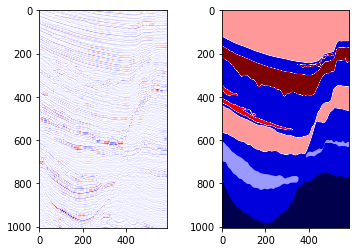

In [3]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(train[:,380,:],cmap='seismic')

axs[1].imshow(labels[:,380,:],cmap='seismic')
plt.show()

 ## Normalization with respect to the test data

In [4]:
adjusted_test_img = np.concatenate([train, test], axis=2)

_min, _max = adjusted_test_img.min(), adjusted_test_img.max()

train = (train - _min) / (_max - _min)
test = (test - _min) / (_max - _min)
adjusted_test_img = (adjusted_test_img - _min) / (_max - _min)

del adjusted_test_img

## Create K-folds index from every possible vertical slice (Z,X and Z,Y)

In [5]:
verticals = [0 for _ in range(train.shape[1])] + [1 for _ in range(train.shape[2])]
folds = list(StratifiedKFold(n_splits=5, random_state=42, shuffle=True).split(X=verticals, y=verticals))

In [6]:
img = train[:,5]
img800 = train[:,:,800-482]
print(img.shape)
image = img[:, :, None]
print(image.shape)
tran = image.transpose(2,0,1)
print(tran.shape)

(1006, 590)
(1006, 590, 1)
(1, 1006, 590)


## Dataset class

In [7]:
class SeismicFaciesDataset(Dataset):
    def __init__(self, img, labels, train=True):
        self.img = img
        self.labels = labels
        self.xaxis = self.img.shape[1]
        self.yaxis = self.img.shape[2]

        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(p=0.7, shift_limit=0, scale_limit=0.15, rotate_limit=15),
            A.RandomCrop(p=1, height=896, width=256),
        ])

    def __len__(self):
        return self.xaxis + self.yaxis

    def __getitem__(self, idx):
        if idx < self.xaxis:
            image, mask = self.img[:, idx], self.labels[:, idx]
        else:
            image, mask = self.img[:, :, idx-self.xaxis], self.labels[:, :, idx-self.xaxis]

        image = image[:, :, None]

        augmented = self.aug(image=image, mask=mask)
        image, mask = augmented['image'], augmented['mask']

        return image.transpose(2, 0, 1), mask


### HomeMade function to get data using DataLoader

In [48]:
def get_data_loaders(dataset, batch_size, train_index, test_index):
    train_dataset, test_dataset = Subset(dataset, train_index), Subset(copy(dataset), test_index)
    test_dataset.dataset.aug = A.PadIfNeeded(p=1, min_height=1024, min_width=800)


    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=1, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=1)
    return train_loader, test_loader


## Model

### Loss model (to change maybe)

In [39]:
class LovaszBCELoss(torch.nn.Module):
    def __init__(self, lovasz_weight=0.75, ce_weight=0.25):
        super().__init__()
        self.lovasz_weight = lovasz_weight
        self.ce_weight = ce_weight
        self.ce = torch.nn.CrossEntropyLoss()
        self.lovasz = LovaszLoss()

    def forward(self, output, target):
        if self.lovasz_weight > 0:
            lovasz = self.lovasz(torch.softmax(output, dim=1), target) * self.lovasz_weight
        else:
            lovasz = 0

        if self.ce_weight > 0:
            ce = self.ce(output, target.long()) * self.ce_weight
        else:
            ce = 0

        return lovasz + ce

### Model based on argus

In [40]:
class SeismicFaciesModel(argus.Model):
    nn_module = smp.Unet
    optimizer = optim.SGD
    loss = LovaszBCELoss

In [41]:
params = {
    'nn_module': {
        'encoder_depth': 3,
        'decoder_channels': [128,64,32],
        'encoder_name': 'efficientnet-b2',
        'decoder_attention_type': 'scse',
        'classes': 6,
        'in_channels': 1,
        'activation': None
    },
    'loss': {
        'lovasz_weight': 0.75,
        'ce_weight': 0.25,
    },
    'optimizer': {'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0001},
    'device': 'cuda'
}

## Training

In [42]:
dataset = SeismicFaciesDataset(train, train)

In [49]:
for i, (train_index, test_index) in enumerate(folds):
    print(i)
    model = SeismicFaciesModel(params)
    model.set_device(0)

    train_loader, val_loader = get_data_loaders(dataset, batch_size=1, train_index=train_index, test_index=test_index)

    callbacks = [
        MonitorCheckpoint(dir_path=f'unet_fold_{i}', monitor='val_loss', max_saves=3),
        ReduceLROnPlateau(monitor='val_loss', patience=30, factor=0.64, min_lr=1e-8),
        EarlyStopping(monitor='val_loss', patience=50),
        LoggingToFile(f'unet_fold_{i}.log'),
    ]

    model.fit(train_loader,
          val_loader=val_loader,
          num_epochs=50,
          metrics=['loss'],
          callbacks=callbacks,
          metrics_on_train=False)

0
[2020-11-15 12:30:39,721][ERROR]: [Errno 32] Broken pipe
Traceback (most recent call last):
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\argus\engine\engine.py", line 82, in run
    for batch in data_loader:
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\torch\utils\data\dataloader.py", line 352, in __iter__
    return self._get_iterator()
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\torch\utils\data\dataloader.py", line 294, in _get_iterator
    return _MultiProcessingDataLoaderIter(self)
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\torch\utils\data\dataloader.py", line 801, in __init__
    w.start()
  File "C:\Users\arno\AppData\Local\Programs\Python\Python37\lib\multiprocessing\process.py", line 112, in start
    self._popen = self._Popen(self)
  File "C:\Users\arno\AppData\Local\Programs\Python\Py

BrokenPipeError: [Errno 32] Broken pipe

In [28]:

model = None
import gc
gc.collect()

21198